# Deepfake Detection v2 — Fixes: crash, overfitting, augmentation

In [31]:
import os
import gc
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras import layers, Model, applications
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.metrics import roc_curve, auc, confusion_matrix

# =====================
# CONFIG
# =====================
DATA_DIR = "/kaggle/input/datasets/saifullah007/deepfake-video-dataset/org_size_imgs"  # FIX THIS
IMG_SIZE = (224, 224)
BATCH_SIZE = 64
EPOCHS = 30
AUTOTUNE = tf.data.AUTOTUNE

## LOAD DATA

In [32]:
import tensorflow as tf
import os

AUTOTUNE = tf.data.AUTOTUNE

def load_data():

    DATA_DIR = "/kaggle/input/datasets/saifullah007/deepfake-video-dataset/org_size_imgs"

    # ==============================
    # TRAIN + VALIDATION SPLIT
    # ==============================
    train_ds = tf.keras.utils.image_dataset_from_directory(
        DATA_DIR,
        validation_split=0.2,   # 🔥 80% train / 20% val
        subset="training",
        seed=42,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode="binary"
    )

    val_ds = tf.keras.utils.image_dataset_from_directory(
        DATA_DIR,
        validation_split=0.2,
        subset="validation",
        seed=42,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode="binary"
    )

    # ==============================
    # AUGMENTATION
    # ==============================
    def augment(x, y):
        x = tf.image.random_flip_left_right(x)
        x = tf.image.random_brightness(x, 0.1)
        return x, y

    train_ds = train_ds.map(augment, num_parallel_calls=AUTOTUNE)

    # ==============================
    # PREPROCESSING
    # ==============================
    train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=AUTOTUNE)
    val_ds   = val_ds.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=AUTOTUNE)

    # ==============================
    # PERFORMANCE
    # ==============================
    train_ds = train_ds.shuffle(1000).prefetch(AUTOTUNE)
    val_ds   = val_ds.prefetch(AUTOTUNE)

    return train_ds, val_ds

## Model 

In [33]:
def build_resnet():
    inputs = layers.Input(shape=(224, 224, 3))

    base = applications.ResNet50(
        weights="imagenet",
        include_top=False,
        input_tensor=inputs
    )

    base.trainable = False  # 🔥 IMPORTANT

    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
    )

    return model

## Training

In [34]:
def train():

    import os
    import gc
    import tensorflow as tf

    tf.keras.backend.clear_session()
    gc.collect()

    train_ds, val_ds = load_data()

    model = build_resnet()

    # ✅ Create save directory
    os.makedirs("models", exist_ok=True)

    # ✅ Callbacks (BEST PRACTICE)
    # callbacks = [
    #     tf.keras.callbacks.EarlyStopping(
    #         monitor="val_loss",
    #         patience=2,
    #         restore_best_weights=True
    #     ),

    #     # 🔥 Save BEST model only
    #     tf.keras.callbacks.ModelCheckpoint(
    #         filepath="models/resnet_best.keras",  # modern format
    #         monitor="val_loss",
    #         save_best_only=True,
    #         verbose=1
    #     )
    # ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        # callbacks=callbacks,
        verbose=1
    )

    # ✅ Save FINAL model also
    model.save("models/resnet_final.keras")

    print("✅ Models saved:")
    print(" - Best:  models/resnet_best.keras")
    print(" - Final: models/resnet_final.keras")

    return model, history, val_ds

# Evaluate

In [35]:
def evaluate(model, history, val_ds):

    # 📊 Accuracy
    plt.figure()
    plt.plot(history.history["accuracy"], label="Train")
    plt.plot(history.history["val_accuracy"], label="Val")
    plt.legend(); plt.title("Accuracy"); plt.grid()
    plt.show()

    # 📉 Loss
    plt.figure()
    plt.plot(history.history["loss"], label="Train")
    plt.plot(history.history["val_loss"], label="Val")
    plt.legend(); plt.title("Loss"); plt.grid()
    plt.show()

    # 🔍 Predictions (SAFE)
    y_true, y_prob = [], []

    for x, y in val_ds:
        preds = model.predict(x, verbose=0)
        y_true.extend(y.numpy())
        y_prob.extend(preds)

    y_true = np.array(y_true).ravel()
    y_prob = np.array(y_prob).ravel()

    # 📈 ROC
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], "--")
    plt.legend(); plt.title("ROC Curve"); plt.grid()
    plt.show()

    # 📊 Confusion Matrix
    y_pred = (y_prob > 0.5).astype(int)
    cm = confusion_matrix(y_true, y_pred)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.show()

    print(f"\n🔥 Final ROC-AUC: {roc_auc:.4f}")

## Run

Found 10000 files belonging to 2 classes.
Using 8000 files for training.


I0000 00:00:1776866405.992901      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 10000 files belonging to 2 classes.
Using 2000 files for validation.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/30


I0000 00:00:1776866452.250184     164 service.cc:152] XLA service 0x7fcde40022b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776866452.250252     164 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1776866454.710223     164 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/125 ━━━━━━━━━━━━━━━━━━━━ 11s 90ms/step - accuracy: 0.4883 - auc: 0.4815 - loss: 0.9885   

I0000 00:00:1776866461.289174     164 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


125/125 ━━━━━━━━━━━━━━━━━━━━ 71s 207ms/step - accuracy: 0.7192 - auc: 0.7866 - loss: 0.5750 - val_accuracy: 0.9825 - val_auc: 0.9991 - val_loss: 0.1612
Epoch 2/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 37s 126ms/step - accuracy: 0.9596 - auc: 0.9929 - loss: 0.1319 - val_accuracy: 0.9990 - val_auc: 1.0000 - val_loss: 0.0550
Epoch 3/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 37s 127ms/step - accuracy: 0.9906 - auc: 0.9994 - loss: 0.0595 - val_accuracy: 0.9995 - val_auc: 1.0000 - val_loss: 0.0252
Epoch 4/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 38s 127ms/step - accuracy: 0.9930 - auc: 0.9997 - loss: 0.0438 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.0140
Epoch 5/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 38s 128ms/step - accuracy: 0.9964 - auc: 0.9999 - loss: 0.0295 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.0094
Epoch 6/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 37s 127ms/step - accuracy: 0.9981 - auc: 1.0000 - loss: 0.0215 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.0067
Epoch 7/30
125/125 ━━━━━━━━━━━━━━

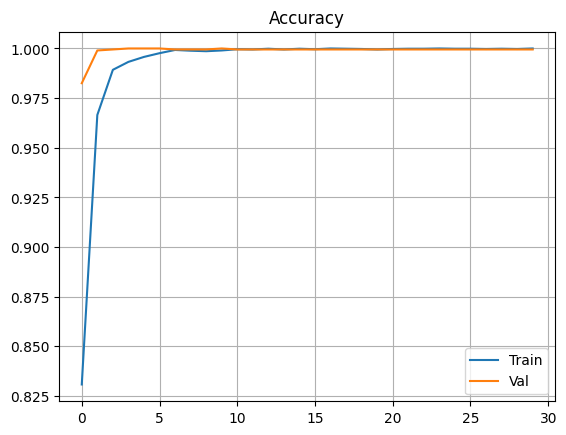

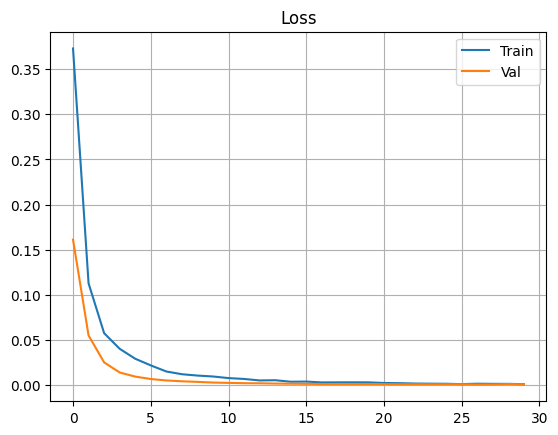

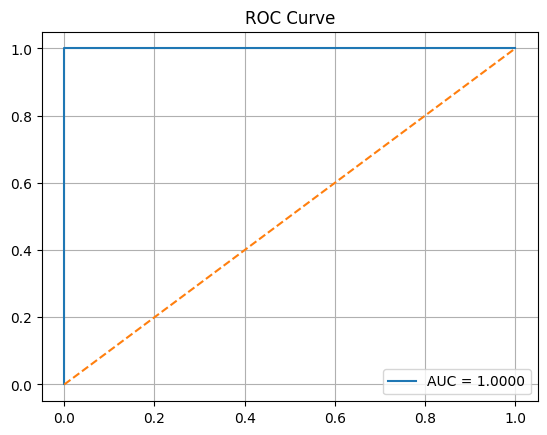

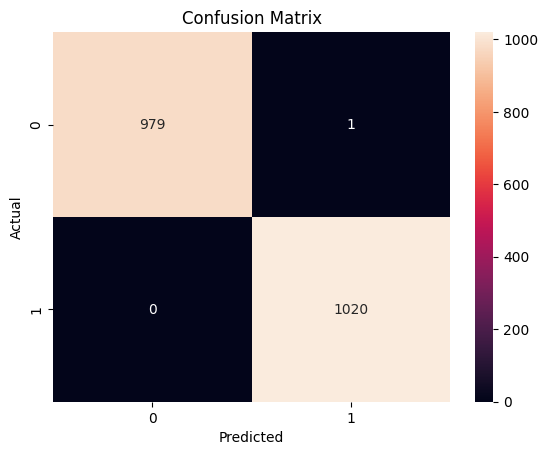


🔥 Final ROC-AUC: 1.0000


In [36]:
model, history, val_ds = train()
evaluate(model, history, val_ds)